# SENSERO Dataset — Sanity Check & Loading Example

Validates dataset integrity and shows how to load patches, metadata, captions, and labels.

**On-disk layout** (GeoTiff example, Patch\_336):
```
GeoTiff/Patch_336/
├── metadata_336.parquet
├── CLC_reference/
│   └── {BaseFolder}/
│       └── {BaseFilename}_CLC.tif
├── CLC_reference_RGB/
│   └── {BaseFolder}/
│       └── {BaseFilename}_CLC_RGB.tif
├── FalseColor_NIR/
│   └── {BaseFolder}/
│       └── {BaseFilename}_B843.tif
├── Multispectral/
│   └── {BaseFolder}/
│       └── {BaseFilename}.tif
└── TrueColor_RGB/
    └── {BaseFolder}/
        └── {BaseFilename}_B432.tif
```
PNG layout is the same but with only 3 folders (no `CLC_reference`, no `Multispectral`) and `.png` extension.

## 1 — Configuration

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# ── EDIT THESE ──────────────────────────────────────────────────
# DATASET_ROOT = Path("/path/to/SENSERO")   # <-- change this
DATASET_ROOT = Path("/home/ubuntu/SENSERO")   # <-- change this
FORMAT       = "tif"                       # "tif" or "png"
PATCH_SIZE   = 280                         # e.g. 336
MAX_ROWS     = None                        # set to e.g. 100 for a quick smoke test
READ_PIXELS  = False                       # True = open every image (slow but thorough)
# ────────────────────────────────────────────────────────────────

EXT = FORMAT  # 'tif' or 'png'

# Folder name  →  filename suffix (before the extension)
LAYERS_TIF = {
    "CLC_reference":     "_CLC",
    "CLC_reference_RGB": "_CLC_RGB",
    "FalseColor_NIR":    "_B843",
    "Multispectral":     "",
    "TrueColor_RGB":     "_B432",
}

LAYERS_PNG = {
    "CLC_reference_RGB": "_CLC_RGB",
    "FalseColor_NIR":    "_B843",
    "TrueColor_RGB":     "_B432",
}

LAYERS = LAYERS_TIF if FORMAT == "tif" else LAYERS_PNG

format_dir = "GeoTiff" if FORMAT == "tif" else "PNG"
PATCH_DIR  = DATASET_ROOT / format_dir / f"Patch_{PATCH_SIZE}"

print(f"Patch directory : {PATCH_DIR}")
print(f"Format          : {FORMAT}")
print(f"Layers          : {list(LAYERS.keys())}")

Patch directory : /home/ubuntu/SENSERO/GeoTiff/Patch_280
Format          : tif
Layers          : ['CLC_reference', 'CLC_reference_RGB', 'FalseColor_NIR', 'Multispectral', 'TrueColor_RGB']


## 2 — Check folder structure

In [2]:
print(f"{'Folder':<25s}  {'Status':>8s}  {'Items':>8s}")
print("-" * 50)

missing_dirs = []
for folder in LAYERS:
    d = PATCH_DIR / folder
    if d.is_dir():
        n = len(list(d.iterdir()))
        print(f"{folder:<25s}  {'OK':>8s}  {n:>8d}")
    else:
        print(f"{folder:<25s}  {'MISSING':>8s}")
        missing_dirs.append(folder)

if missing_dirs:
    print(f"\n✗ FATAL — missing directories: {missing_dirs}")
else:
    print("\n✓ All expected folders present.")

Folder                       Status     Items
--------------------------------------------------
CLC_reference                    OK        38
CLC_reference_RGB                OK        38
FalseColor_NIR                   OK        38
Multispectral                    OK        38
TrueColor_RGB                    OK        38

✓ All expected folders present.


## 3 — Load metadata parquet

In [3]:
parquet_path = PATCH_DIR / f"metadata_{PATCH_SIZE}.parquet"

if not parquet_path.exists():
    # PNG folders don't have their own parquet — fall back to GeoTiff
    parquet_path = (
        DATASET_ROOT / "GeoTiff" / f"Patch_{PATCH_SIZE}" / f"metadata_{PATCH_SIZE}.parquet"
    )
    print(f"[info] Falling back to GeoTiff parquet: {parquet_path}")

df = pd.read_parquet(parquet_path)
print(f"Loaded {len(df)} rows, {len(df.columns)} columns.")
print(f"Columns: {list(df.columns)}\n")
display(df.head(5))

Loaded 10000 rows, 9 columns.
Columns: ['BaseFolder', 'BaseFilename', 'CLC_codes', 'label_l1', 'label_l2', 'label_l3', 'label_ben', 'label_sensero', 'split']



,BaseFolder,BaseFilename,CLC_codes,label_l1,label_l2,label_l3,label_ben,label_sensero,split
0,S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM,S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM_1...,"211, 311, 112, 243, 242","forest and semi-natural zones, agricultural ar...","forests, arable land, urban fabric, heterogene...","broad-leaved forest, non-irrigated arable land...","broad-leaved forest, arable land, urban fabric...","forests, agriculture, urban fabric, mixed farm...",train
1,S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM,S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM_1...,"211, 311, 222, 112, 243, 231","forest and semi-natural zones, agricultural ar...","forests, arable land, permanent crops, urban f...","broad-leaved forest, non-irrigated arable land...","broad-leaved forest, arable land, permanent cr...","forests, agriculture, permanent crops, urban f...",val
2,S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM,S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM_1...,"311, 211, 324, 242","forest and semi-natural zones, agricultural areas","forests, arable land, scrub and/or herbaceous ...","broad-leaved forest, non-irrigated arable land...","broad-leaved forest, arable land, transitional...","forests, agriculture, shrubland, mixed farmland",val
3,S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM,S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM_1...,"311, 222, 324, 243, 242, 211","forest and semi-natural zones, agricultural areas",scrub and/or herbaceous vegetation association...,"transitional woodland-shrub, broad-leaved fore...","transitional woodland-shrub, broad-leaved fore...","shrubland, forests, mixed farmland, permanent ...",train
4,S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM,S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM_1...,"221, 211, 112, 331, 243, 311","artificial surfaces, forest and semi-natural z...","urban fabric, open spaces with little or no ve...","discontinuous urban fabric, beaches dunes sand...","urban fabric, beaches dunes sands, arable land...","urban fabric, agriculture, mixed farmland, per...",val


## 4 — Inspect key columns

In [4]:
caption_cols = [c for c in df.columns if "caption" in c.lower()]
clc_cols     = [c for c in df.columns if "clc" in c.lower()]
split_cols   = [c for c in df.columns if c.lower() in ("split", "split1")]

print("Caption columns :", caption_cols or "(none found)")
print("CLC columns     :", clc_cols or "(none found)")
print("Split columns   :", split_cols or "(none found)")
print()

for col in split_cols:
    print(f"--- {col} distribution ---")
    print(df[col].value_counts().to_string())
    print()

# Verify required columns
assert "BaseFilename" in df.columns, "Missing BaseFilename column!"
assert "BaseFolder"   in df.columns, "Missing BaseFolder column!"
print("✓ BaseFilename and BaseFolder present.")

Caption columns : (none found)
CLC columns     : ['CLC_codes']
Split columns   : ['split']

--- split distribution ---
split
train    7000
val      1500
test     1500

✓ BaseFilename and BaseFolder present.


## 5 — Verify filename suffixes

Grab one real file from each layer and confirm the suffix mapping is correct.

In [5]:
print(f"{'Layer':<25s}  {'Expected suffix':<20s}  {'Sample file':<60s}  Status")
print("-" * 120)

sample_folder = df["BaseFolder"].iloc[0]
sample_base   = df["BaseFilename"].iloc[0]

for folder, suffix in LAYERS.items():
    expected = PATCH_DIR / folder / sample_folder / f"{sample_base}{suffix}.{EXT}"
    status = "✓" if expected.exists() else "✗ NOT FOUND"
    print(f"{folder:<25s}  {suffix:<20s}  {expected.name:<60s}  {status}")

    # If expected doesn't exist, try to find what IS there
    if not expected.exists():
        alt_dir = PATCH_DIR / folder / sample_folder
        if alt_dir.is_dir():
            candidates = [f.name for f in alt_dir.iterdir() if sample_base in f.name]
            if candidates:
                print(f"{'':25s}  → found instead: {candidates[0]}")
            else:
                print(f"{'':25s}  → no files matching '{sample_base}' in {alt_dir}")
        else:
            print(f"{'':25s}  → subfolder does not exist: {alt_dir}")

Layer                      Expected suffix       Sample file                                                   Status
------------------------------------------------------------------------------------------------------------------------
CLC_reference              _CLC                  S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM_1002_3034_CLC.tif  ✓
CLC_reference_RGB          _CLC_RGB              S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM_1002_3034_CLC_RGB.tif  ✓
FalseColor_NIR             _B843                 S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM_1002_3034_B843.tif  ✓
Multispectral                                    S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM_1002_3034.tif    ✓
TrueColor_RGB              _B432                 S2A_MSIL2A_20180809T090551_N0500_R050_T35TNM_1002_3034_B432.tif  ✓


## 6 — Image reading helpers

In [6]:
try:
    import rasterio
    HAS_RASTERIO = True
except ImportError:
    HAS_RASTERIO = False

from PIL import Image as PILImage


def read_tif(path: Path) -> np.ndarray:
    """Read a GeoTiff → numpy array (C, H, W)."""
    with rasterio.open(path) as src:
        return src.read()


def read_png(path: Path) -> np.ndarray:
    """Read a PNG → numpy array (H, W, C)."""
    return np.array(PILImage.open(path))


def read_image(path: Path) -> np.ndarray:
    if FORMAT == "tif":
        return read_tif(path)
    return read_png(path)


def resolve_path(folder: str, suffix: str, base_folder: str, base_filename: str) -> Path:
    """Build the full path to a specific layer file."""
    return PATCH_DIR / folder / base_folder / f"{base_filename}{suffix}.{EXT}"


print("Readers ready.  rasterio available:", HAS_RASTERIO)

Readers ready.  rasterio available: True


## 7 — Row-level sanity check

For each row: resolve the path for every layer, check it exists, optionally read pixels, and verify captions/CLC are non-empty.

In [7]:
n_rows = len(df) if MAX_ROWS is None else min(MAX_ROWS, len(df))
errors   = []
warnings = []

print(f"Checking {n_rows} / {len(df)} rows …\n")

for idx in range(n_rows):
    row = df.iloc[idx]
    bf   = row["BaseFolder"]
    stem = row["BaseFilename"]

    # Check every layer
    for folder, suffix in LAYERS.items():
        fpath = resolve_path(folder, suffix, bf, stem)
        if not fpath.exists():
            errors.append(f"Row {idx} ({stem}): missing {folder}/{bf}/{fpath.name}")
            continue
        if READ_PIXELS:
            try:
                arr = read_image(fpath)
                if arr.ndim < 2:
                    errors.append(
                        f"Row {idx} ({stem}): {folder} — unexpected ndim={arr.ndim}"
                    )
            except Exception as e:
                errors.append(f"Row {idx} ({stem}): {folder} — read error: {e}")

    # Check captions
    for col in caption_cols:
        val = row.get(col, None)
        if val is None or (isinstance(val, str) and val.strip() == ""):
            warnings.append(f"Row {idx} ({stem}): empty caption in '{col}'")

    # Check CLC
    for col in clc_cols:
        if row.get(col, None) is None:
            warnings.append(f"Row {idx} ({stem}): missing CLC in '{col}'")

    if (idx + 1) % 500 == 0 or idx == n_rows - 1:
        print(f"  {idx + 1:>6d} / {n_rows} checked")

print("\nDone.")

Checking 10000 / 10000 rows …

     500 / 10000 checked
    1000 / 10000 checked
    1500 / 10000 checked
    2000 / 10000 checked
    2500 / 10000 checked
    3000 / 10000 checked
    3500 / 10000 checked
    4000 / 10000 checked
    4500 / 10000 checked
    5000 / 10000 checked
    5500 / 10000 checked
    6000 / 10000 checked
    6500 / 10000 checked
    7000 / 10000 checked
    7500 / 10000 checked
    8000 / 10000 checked
    8500 / 10000 checked
    9000 / 10000 checked
    9500 / 10000 checked
   10000 / 10000 checked

Done.


## 8 — Report

In [8]:
print(f"Rows checked : {n_rows}")
print(f"Errors       : {len(errors)}")
print(f"Warnings     : {len(warnings)}")
print()

if errors:
    print("--- ERRORS (first 20) ---")
    for e in errors[:20]:
        print(f"  ✗ {e}")
    if len(errors) > 20:
        print(f"  … and {len(errors) - 20} more.")
    print()

if warnings:
    print("--- WARNINGS (first 20) ---")
    for w in warnings[:20]:
        print(f"  ⚠ {w}")
    if len(warnings) > 20:
        print(f"  … and {len(warnings) - 20} more.")
    print()

if not errors and not warnings:
    print("✓ All checks passed — dataset looks healthy!")

Rows checked : 10000
Errors       : 0
Warnings     : 0

✓ All checks passed — dataset looks healthy!


## 9 — Visual spot-check

Random patches displayed across the RGB-friendly layers.

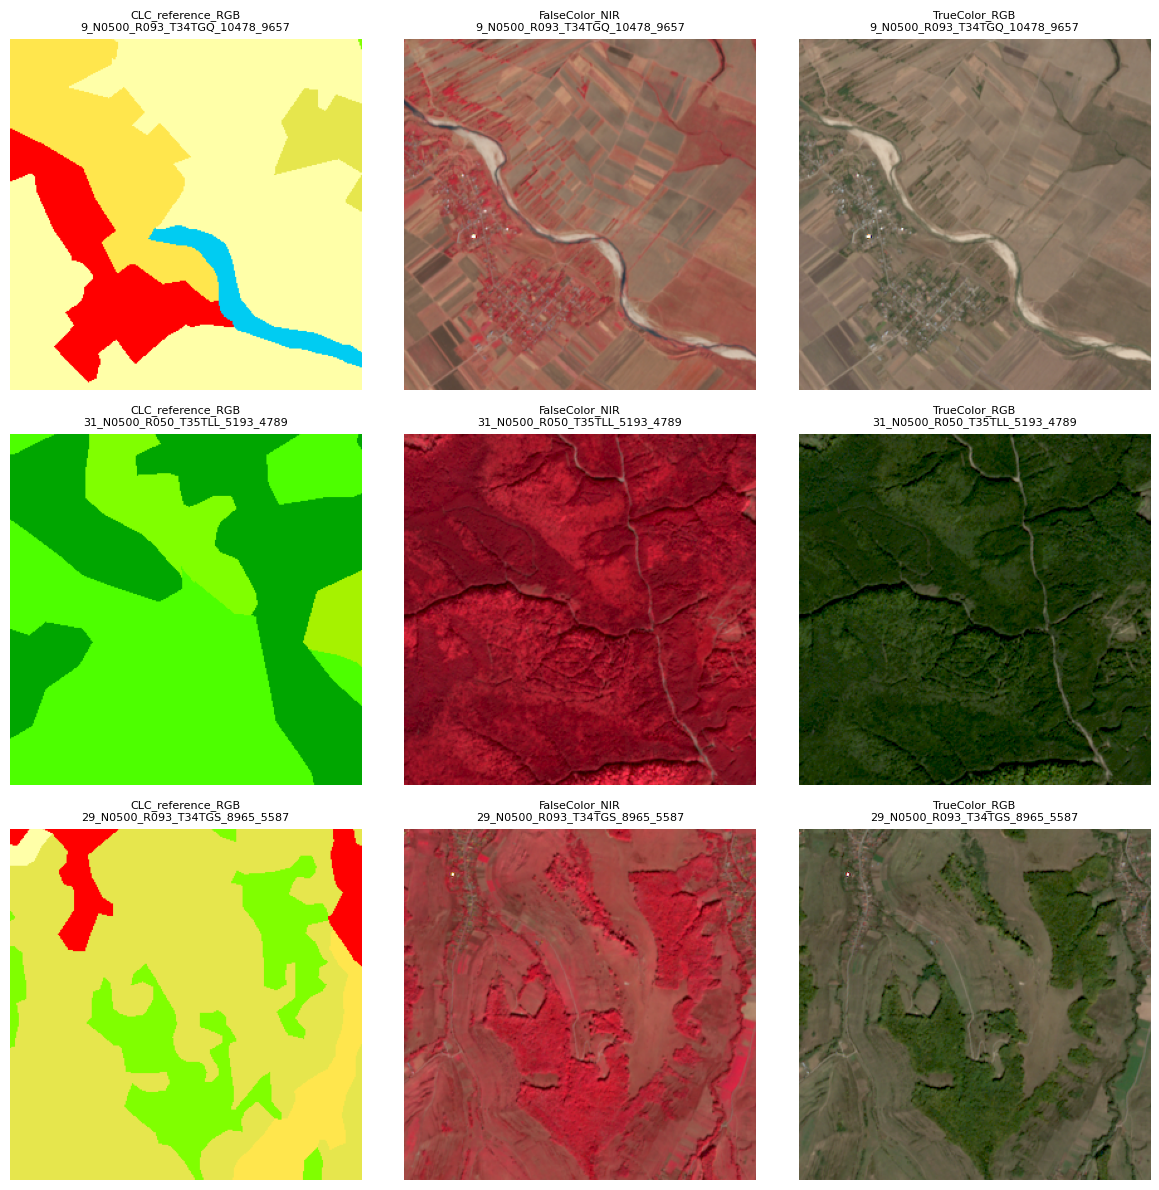

In [9]:
N_SAMPLES = 3
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(df), size=min(N_SAMPLES, len(df)), replace=False)

# Only visualise layers that produce displayable RGB images
VIS_LAYERS = {k: v for k, v in LAYERS.items() if k not in ("Multispectral", "CLC_reference")}

fig, axes = plt.subplots(
    len(sample_indices), len(VIS_LAYERS),
    figsize=(4 * len(VIS_LAYERS), 4 * len(sample_indices)),
    squeeze=False,
)

for row_i, idx in enumerate(sample_indices):
    row = df.iloc[idx]
    bf   = row["BaseFolder"]
    stem = row["BaseFilename"]

    for col_j, (folder, suffix) in enumerate(VIS_LAYERS.items()):
        ax = axes[row_i][col_j]
        fpath = resolve_path(folder, suffix, bf, stem)
        if fpath.exists():
            img = read_image(fpath)
            if FORMAT == "tif" and img.ndim == 3:
                img = np.moveaxis(img, 0, -1)
            if img.ndim == 3 and img.shape[-1] > 3:
                img = img[..., :3]
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "MISSING", ha="center", va="center",
                    transform=ax.transAxes, fontsize=14, color="red")
        ax.set_title(f"{folder}\n{stem[-30:]}", fontsize=8)
        ax.axis("off")

plt.tight_layout()
plt.show()

## 10 — Single-row loading example

Copy-pasteable `load_patch()` for training / evaluation code.

In [10]:
def load_patch(df_row, patch_dir: Path, layers: dict, ext: str):
    """
    Load all image layers + metadata for one patch.

    Returns
    -------
    dict with keys:
        images   : {folder_name: np.ndarray}
        caption1 … caption5 : str
        clc      : str
        split    : str
        split1   : str
    """
    bf   = df_row["BaseFolder"]
    stem = df_row["BaseFilename"]

    images = {}
    for folder, suffix in layers.items():
        fpath = patch_dir / folder / bf / f"{stem}{suffix}.{ext}"
        images[folder] = read_image(fpath) if fpath.exists() else None

    return {
        "images"   : images,
        "caption1" : df_row.get("caption1", None),
        "caption2" : df_row.get("caption2", None),
        "caption3" : df_row.get("caption3", None),
        "caption4" : df_row.get("caption4", None),
        "caption5" : df_row.get("caption5", None),
        "clc"      : df_row.get("CLC_codes", None),
        "split"    : df_row.get("split", None),
        "split1"   : df_row.get("split1", None),
    }


# Quick demo
sample = load_patch(df.iloc[0], PATCH_DIR, LAYERS, EXT)
print("Keys    :", list(sample.keys()))
print("Images  :", {k: (v.shape if v is not None else None) for k, v in sample["images"].items()})
for i in range(1, 6):
    val = sample[f"caption{i}"]
    print(f"Caption{i}: {str(val)[:100]}")
print("CLC     :", sample["clc"])
print("Split   :", sample["split"])
print("Split1  :", sample["split1"])

Keys    : ['images', 'caption1', 'caption2', 'caption3', 'caption4', 'caption5', 'clc', 'split', 'split1']
Images  : {'CLC_reference': (1, 280, 280), 'CLC_reference_RGB': (3, 280, 280), 'FalseColor_NIR': (3, 280, 280), 'Multispectral': (12, 280, 280), 'TrueColor_RGB': (3, 280, 280)}
Caption1: None
Caption2: None
Caption3: None
Caption4: None
Caption5: None
CLC     : 211, 311, 112, 243, 242
Split   : train
Split1  : None


In [11]:
# =====================================================
# Full dataset load — read every file from disk
# =====================================================
from tqdm.notebook import tqdm

failed = []

for idx in tqdm(range(len(df)), desc="Loading all patches"):
    row = df.iloc[idx]
    bf   = row["BaseFolder"]
    stem = row["BaseFilename"]

    for folder, suffix in LAYERS.items():
        fpath = resolve_path(folder, suffix, bf, stem)
        if not fpath.exists():
            failed.append((idx, stem, folder, f"MISSING: {fpath.name}"))
            continue
        try:
            arr = read_image(fpath)
            assert arr.ndim >= 2, f"ndim={arr.ndim}"
            assert arr.size > 0, "empty array"
        except Exception as e:
            failed.append((idx, stem, folder, str(e)))

if failed:
    print(f"\n✗ {len(failed)} failures. First 10:")
    for idx, stem, folder, reason in failed[:10]:
        print(f"  Row {idx} | {folder} | {reason}")
    raise RuntimeError(f"{len(failed)} failures — dataset is incomplete or corrupt.")

print(f"\n✓ All {len(df)} × {len(LAYERS)} = {len(df) * len(LAYERS):,} files loaded successfully.")

Loading all patches:   0%|          | 0/10000 [00:00<?, ?it/s]


✓ All 10000 × 5 = 50,000 files loaded successfully.
